In [20]:
import os
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms


In [21]:
df = pd.read_csv("Banana/labels.csv")

# Fix file extensions in img_path column
def fix_img_path(row):
    if "yellaki" in row['img_path']:
        # keep .JPG as is
        return row['img_path'].replace('.jpg', '.JPG')
    else:
        # normalize to lowercase .jpg
        return row['img_path'].replace('.JPG', '.jpg')

df['img_path'] = df.apply(fix_img_path, axis=1)


df = df[['variety','img_path','days_until_death']]

variety_map = {'yellaki': 0, 'robusta': 1, 'Redbanana': 2,'poovan':3,'karpooravalli':4,'nendran':5}
df['variety_num'] = df['variety'].map(variety_map)
df.drop(columns=['variety'], inplace=True)

train_df = df.sample(frac=1, random_state=0).iloc[:519]
test_df  = df.sample(frac=1, random_state=0).iloc[519:]

train_df.head()

,img_path,days_until_death,variety_num
532,variety_karpooravalli/banana_40/day_5/1.jpg,1,4
375,variety_Redbanana/banana_27/day_5/2.jpg,0,2
306,variety_Redbanana/banana_21/day_6/2.jpg,0,2
625,variety_nendran/banana_47/day_4/1.jpg,4,5
480,variety_poovan/banana_36/day_4/1.jpg,1,3


In [22]:
# =====================================================
# 2. DATASET CLASS
# =====================================================
class BananaDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['img_path'])

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        variety = torch.tensor(row['variety_num']).long()          # classification (0–2)
        days = torch.tensor(row['days_until_death']).float()       # regression

        return image, variety, days


In [23]:
# =====================================================
# 3. TRANSFORMS (Equivalent to Keras Augmentations)
# =====================================================
train_transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(0, translate=(0.2, 0.2), shear=0.2),
    transforms.RandomResizedCrop(200, scale=(0.8, 1.2)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
])

In [24]:
# =====================================================
# 4. DATALOADERS
# =====================================================
img_folder = "Banana"

train_dataset = BananaDataset(train_df, img_folder, train_transform)
test_dataset  = BananaDataset(test_df,  img_folder, test_transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [25]:
# =====================================================
# 5. MODEL (ResNet50 + Multi-output Heads)
# =====================================================
class MultiOutputResNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        
        # Freeze ResNet
        for p in self.base.parameters():
            p.requires_grad = False
        
        in_features = self.base.fc.in_features
        
        # Replace FC layer with identity
        self.base.fc = nn.Identity()
        
        # Regression head
        self.reg_head1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)      # output: days_until_death
        )
        
        # Classification head
        self.cls_head1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 6)      # 3 classes → softmax not required here
        )
        
    def forward(self, x):
        features = self.base(x)
        
        out_reg = self.reg_head1(features)
        out_cls = self.cls_head1(features)
        
        return out_reg, out_cls


In [26]:
model = MultiOutputResNet()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

MultiOutputResNet(
  (base): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
   

In [27]:
# =====================================================
# 6. LOSS, OPTIMIZER
# =====================================================
criterion_reg = nn.L1Loss()    # MAE
criterion_cls = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

loss_w_reg = 1
loss_w_cls = 99   # same as Keras

In [28]:
# =====================================================
# 7. TRAINING + VALIDATION LOOP WITH METRICS
# =====================================================

train_acc_list = []
val_acc_list = []
train_mae_list = []
val_mae_list = []


for epoch in range(15):
    # ------------------------------
    # TRAIN
    # ------------------------------
    model.train()
    train_reg_loss = 0
    train_cls_correct = 0
    train_total = 0

    for imgs, cls_labels, days in train_loader:
        imgs = imgs.to(device)
        cls_labels = cls_labels.to(device)
        days = days.to(device)

        optimizer.zero_grad()

        pred_days, pred_cls = model(imgs)

        loss_reg = criterion_reg(pred_days.squeeze(), days)
        loss_cls = criterion_cls(pred_cls, cls_labels)

        loss = (loss_w_reg * loss_reg) + (loss_w_cls * loss_cls)
        loss.backward()
        optimizer.step()

        train_reg_loss += loss_reg.item()

        preds = torch.argmax(pred_cls, dim=1)
        train_cls_correct += (preds == cls_labels).sum().item()
        train_total += cls_labels.size(0)

    train_mae = train_reg_loss / len(train_loader)
    train_acc = train_cls_correct / train_total
    train_mae_list.append(train_mae)
    train_acc_list.append(train_acc)

    # ------------------------------
    # VALIDATION
    # ------------------------------
    model.eval()
    val_reg_loss = 0
    val_cls_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, cls_labels, days in test_loader:
            imgs = imgs.to(device)
            cls_labels = cls_labels.to(device)
            days = days.to(device)

            pred_days, pred_cls = model(imgs)

            val_reg_loss += criterion_reg(pred_days.squeeze(), days).item()

            preds = torch.argmax(pred_cls, dim=1)
            val_cls_correct += (preds == cls_labels).sum().item()
            val_total += cls_labels.size(0)

    val_mae = val_reg_loss / len(test_loader)
    val_acc = val_cls_correct / val_total

    val_mae_list.append(val_mae)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}/15")
    print(f"  Train     MAE: {train_mae:.4f}   Acc: {train_acc:.4f}")
    print(f"  Val       MAE: {val_mae:.4f}     Acc: {val_acc:.4f}")
    print("-" * 50)


Epoch 1/15
  Train     MAE: 2.2275   Acc: 0.6474
  Val       MAE: 1.7095     Acc: 0.7923
--------------------------------------------------
Epoch 2/15
  Train     MAE: 1.7689   Acc: 0.8420
  Val       MAE: 1.5157     Acc: 0.9538
--------------------------------------------------
Epoch 3/15
  Train     MAE: 1.5436   Acc: 0.9383
  Val       MAE: 1.1948     Acc: 0.9308
--------------------------------------------------
Epoch 4/15
  Train     MAE: 1.2761   Acc: 0.9383
  Val       MAE: 1.0485     Acc: 0.9692
--------------------------------------------------
Epoch 5/15
  Train     MAE: 1.0654   Acc: 0.9692
  Val       MAE: 0.9244     Acc: 0.9615
--------------------------------------------------
Epoch 6/15
  Train     MAE: 1.0237   Acc: 0.9884
  Val       MAE: 0.8888     Acc: 0.9769
--------------------------------------------------
Epoch 7/15
  Train     MAE: 0.9621   Acc: 0.9788
  Val       MAE: 0.9995     Acc: 0.9769
--------------------------------------------------
Epoch 8/15
  Train  

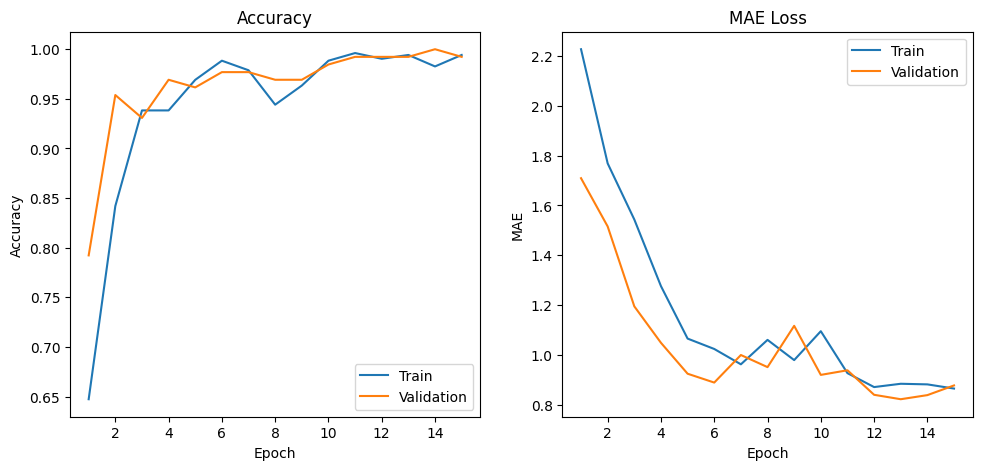

In [31]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_list) + 1)

plt.figure(figsize=(18, 5))

# Accuracy
plt.subplot(1, 3, 1)
plt.plot(epochs, train_acc_list, label='Train')
plt.plot(epochs, val_acc_list, label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# MAE
plt.subplot(1, 3, 2)
plt.plot(epochs, train_mae_list, label='Train')
plt.plot(epochs, val_mae_list, label='Validation')
plt.title(' MAE Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()


In [32]:
class_names = ['yellaki', 'robusta', 'Redbanana', 'poovan', 'karpooravalli', 'nendran']


In [33]:
from PIL import Image
import torch

def predict_image(model, image_path, transform, device):
    model.eval()

    img = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device)   # shape → [1, 3, 200, 200]

    with torch.no_grad():
        pred_days, pred_cls = model(img_t)

    # Regression output
    days_pred = pred_days.item()

    # Classification output
    cls_index = torch.argmax(pred_cls, dim=1).item()
    cls_label = class_names[cls_index]

    return days_pred, cls_label


In [40]:
test_image = "Banana/variety_poovan/banana_34/day_4/1.jpg"
days, variety = predict_image(model, test_image, test_transform, device)

print("Predicted Variety =", variety)
print("Predicted Days Until Death =", days)


Predicted Variety = poovan
Predicted Days Until Death = 1.3679147958755493
